<a href="https://www.kaggle.com/code/lalit7881/nhtsa-vehicle-safety-recall-intelligence-2010-22?scriptVersionId=315277229" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jahnavikachhia23/nhtsa-vehicle-safety-recall-intelligence-20102026/nhtsa_vehicle_safety_recall_intelligence_ultimate.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jahnavikachhia23/nhtsa-vehicle-safety-recall-intelligence-20102026/nhtsa_vehicle_safety_recall_intelligence_ultimate.csv")

In [3]:
df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [4]:
df.tail()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
47702,9435c79ecfa868,159592,20V195000,V2003,CHEVROLET,6500XD,2019.0,2019.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,000102456004127742000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47703,05a14affdb297b,159591,20V195000,V2003,CHEVROLET,6500XD,2018.0,2018.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,000102456004127741000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47704,ca834dfa7369e1,159590,20V195000,V2003,ISUZU,FTR,2019.0,2019.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,000102456003752720000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47705,c9af5f7a4b05e8,159589,20V195000,V2003,ISUZU,FTR,2018.0,2018.0,2010s,"Isuzu Technical Center of America, Inc.",...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20200403,000102456003752719000000207,Harness,Chassis frame harness leading from relay box t...,8983198205,2020-04-03,0.2884
47706,0813997d75da1d,196321,21V920000,21TB10 / 21TA10,TOYOTA,TUNDRA,2020.0,2020.0,2020s,Toyota Motor Engineering & Manufacturing,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20211123,000116189003960725000000011,"Gear Assy, Power Steering",Hydraulic Rack & Pinion Steering Gear,44250-0C170,2021-11-23,0.2899


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47707 entries, 0 to 47706
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   47707 non-null  object 
 1   nhtsa_record_id             47707 non-null  int64  
 2   recall_campaign_id          47707 non-null  object 
 3   manufacturer_campaign_id    33642 non-null  object 
 4   vehicle_make                47707 non-null  object 
 5   vehicle_model               47707 non-null  object 
 6   vehicle_year                46705 non-null  float64
 7   vehicle_year_num            46705 non-null  float64
 8   vehicle_era                 46705 non-null  object 
 9   manufacturer_name           47707 non-null  object 
 10  manufacturer_text           47707 non-null  object 
 11  make_origin                 47707 non-null  object 
 12  recall_type_code            47707 non-null  object 
 13  recall_type_label           477

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47707 entries, 0 to 47706
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   47707 non-null  object 
 1   nhtsa_record_id             47707 non-null  int64  
 2   recall_campaign_id          47707 non-null  object 
 3   manufacturer_campaign_id    33642 non-null  object 
 4   vehicle_make                47707 non-null  object 
 5   vehicle_model               47707 non-null  object 
 6   vehicle_year                46705 non-null  float64
 7   vehicle_year_num            46705 non-null  float64
 8   vehicle_era                 46705 non-null  object 
 9   manufacturer_name           47707 non-null  object 
 10  manufacturer_text           47707 non-null  object 
 11  make_origin                 47707 non-null  object 
 12  recall_type_code            47707 non-null  object 
 13  recall_type_label           477

In [7]:
df.describe()

,nhtsa_record_id,vehicle_year,vehicle_year_num,recall_initiation_date,owner_notification_date,manufacture_date_begin,manufacture_date_end,recall_year,recall_month,recall_quarter,recall_age_days,days_to_owner_notification,potential_units_affected,units_affected_num,fire_risk_flag,manufacturer_recall_count,is_repeat_manufacturer,recall_risk_score,record_creation_date,defect_severity_score
count,47707.000000,46705.000000,46705.000000,4.770700e+04,4.649500e+04,2.347300e+04,2.336500e+04,47707.000000,47707.000000,47707.000000,47707.000000,46483.000000,4.770700e+04,4.770700e+04,47707.000000,47707.000000,47707.000000,47707.000000,4.770700e+04,47707.000000
mean,167285.682143,2014.684316,2014.684316,2.018520e+07,2.018392e+07,2.010196e+07,2.014509e+07,2018.452324,6.562685,2.521118,2683.213910,75.455823,2.583387e+05,2.583387e+05,0.004318,4148.963842,0.994424,34.135389,2.018519e+07,0.239774
std,70721.828215,6.411211,6.411211,4.511637e+04,1.524392e+05,1.633487e+05,9.220569e+04,4.513901,3.613877,1.172047,1645.061007,99.396269,6.763782e+05,6.763782e+05,0.065570,7823.761485,0.074463,14.030891,4.513059e+04,0.054547
min,81715.000000,1988.000000,1988.000000,2.010010e+07,1.111111e+07,2.090211e+06,1.900010e+07,2010.000000,1.000000,1.000000,5.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000,4.000000,2.010010e+07,0.053800
25%,112204.500000,2010.000000,2010.000000,2.015060e+07,2.015080e+07,2.006050e+07,2.011060e+07,2015.000000,3.000000,1.000000,1355.000000,29.000000,1.159000e+03,1.159000e+03,0.000000,484.000000,1.000000,21.000000,2.015060e+07,0.202000
50%,140588.000000,2015.000000,2015.000000,2.019023e+07,2.019032e+07,2.010070e+07,2.015013e+07,2019.000000,6.000000,2.000000,2610.000000,50.000000,1.545400e+04,1.545400e+04,0.000000,1614.000000,1.000000,32.000000,2.019023e+07,0.234500
75%,217614.500000,2020.000000,2020.000000,2.022080e+07,2.022082e+07,2.014092e+07,2.017120e+07,2022.000000,10.000000,4.000000,3975.000000,69.000000,1.733010e+05,1.733010e+05,0.000000,4177.000000,1.000000,43.000000,2.022080e+07,0.272200
max,321004.000000,2027.000000,2027.000000,2.026042e+07,2.026042e+07,3.019051e+07,3.016063e+07,2026.000000,12.000000,4.000000,5951.000000,2675.000000,1.760000e+07,1.760000e+07,1.000000,44051.000000,1.000000,69.000000,2.026042e+07,0.523300


In [8]:
df.isnull().sum()

record_id                         0
nhtsa_record_id                   0
recall_campaign_id                0
manufacturer_campaign_id      14065
vehicle_make                      0
vehicle_model                     0
vehicle_year                   1002
vehicle_year_num               1002
vehicle_era                    1002
manufacturer_name                 0
manufacturer_text                 0
make_origin                       0
recall_type_code                  0
recall_type_label                 0
component_name                    0
component_category                0
recall_initiation_date            0
recall_date_parsed                0
report_received_date              0
owner_notification_date        1212
notification_date_parsed       1224
manufacture_date_begin        24234
manufacture_date_end          24342
recall_year                       0
recall_month                      0
recall_quarter                    0
recall_age_days                   0
days_to_owner_notification  

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['record_id', 'nhtsa_record_id', 'recall_campaign_id',
       'manufacturer_campaign_id', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'vehicle_year_num', 'vehicle_era', 'manufacturer_name',
       'manufacturer_text', 'make_origin', 'recall_type_code',
       'recall_type_label', 'component_name', 'component_category',
       'recall_initiation_date', 'recall_date_parsed', 'report_received_date',
       'owner_notification_date', 'notification_date_parsed',
       'manufacture_date_begin', 'manufacture_date_end', 'recall_year',
       'recall_month', 'recall_quarter', 'recall_age_days',
       'days_to_owner_notification', 'potential_units_affected',
       'units_affected_num', 'recall_scale', 'defect_summary',
       'consequence_summary', 'corrective_action', 'notes', 'defect_severity',
       'fire_risk_flag', 'manufacturer_recall_count', 'is_repeat_manufacturer',
       'recall_risk_score', 'risk_tier', 'influenced_by', 'data_source',
       'source_url', 'scrape

In [11]:
df.dtypes

record_id                      object
nhtsa_record_id                 int64
recall_campaign_id             object
manufacturer_campaign_id       object
vehicle_make                   object
vehicle_model                  object
vehicle_year                  float64
vehicle_year_num              float64
vehicle_era                    object
manufacturer_name              object
manufacturer_text              object
make_origin                    object
recall_type_code               object
recall_type_label              object
component_name                 object
component_category             object
recall_initiation_date          int64
recall_date_parsed             object
report_received_date           object
owner_notification_date       float64
notification_date_parsed       object
manufacture_date_begin        float64
manufacture_date_end          float64
recall_year                     int64
recall_month                    int64
recall_quarter                  int64
recall_age_d

In [12]:
df.shape

(47707, 53)

In [13]:
df.nunique()

record_id                     47707
nhtsa_record_id               47707
recall_campaign_id             5511
manufacturer_campaign_id       3791
vehicle_make                    789
vehicle_model                  5048
vehicle_year                     40
vehicle_year_num                 40
vehicle_era                       5
manufacturer_name               808
manufacturer_text               616
make_origin                       7
recall_type_code                  4
recall_type_label                 4
component_name                  461
component_category               14
recall_initiation_date         2683
recall_date_parsed             2683
report_received_date              2
owner_notification_date        2734
notification_date_parsed       2733
manufacture_date_begin         3781
manufacture_date_end           3462
recall_year                      17
recall_month                     12
recall_quarter                    4
recall_age_days                2683
days_to_owner_notification  

## EDA

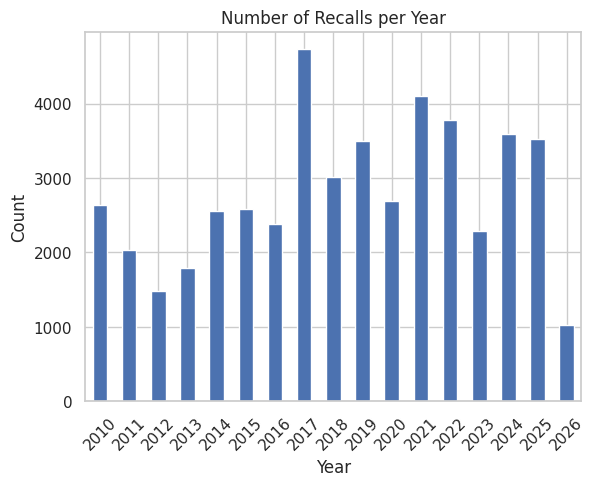

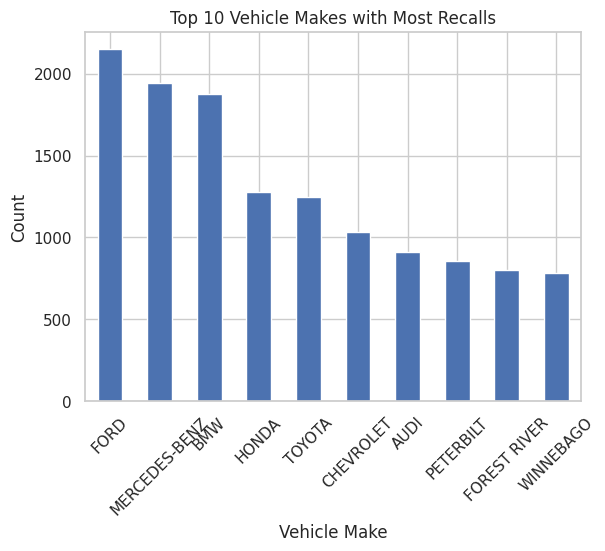

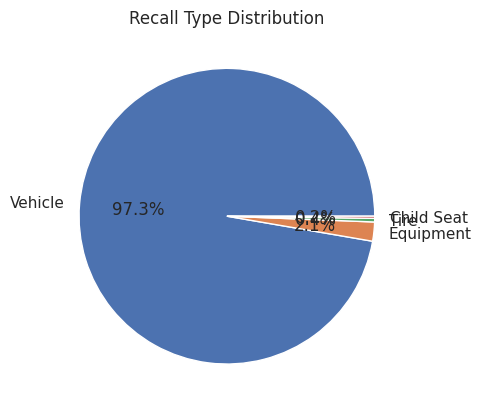

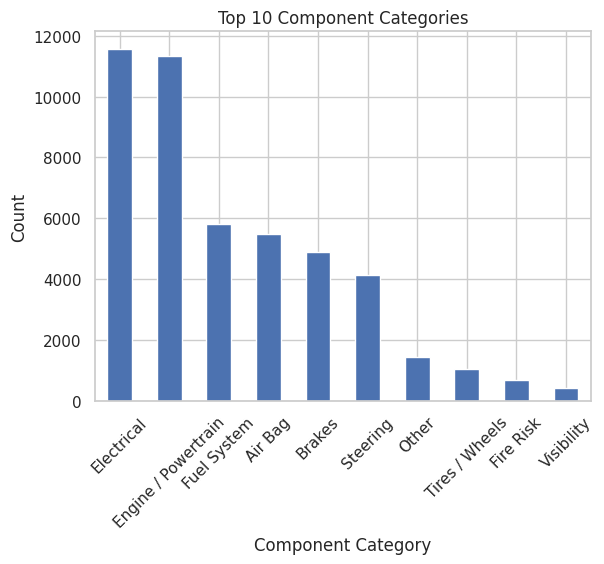

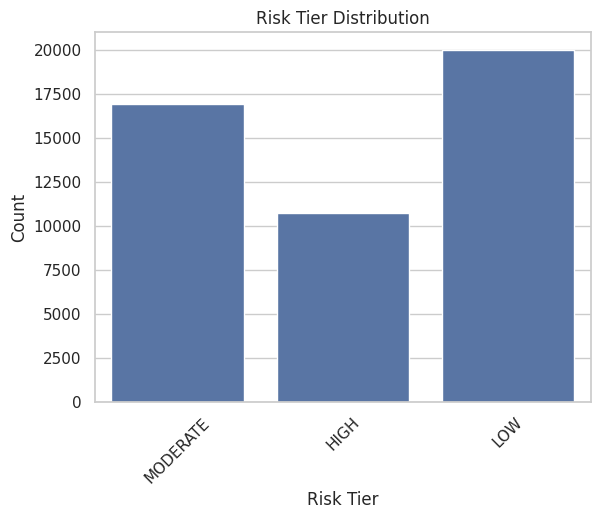

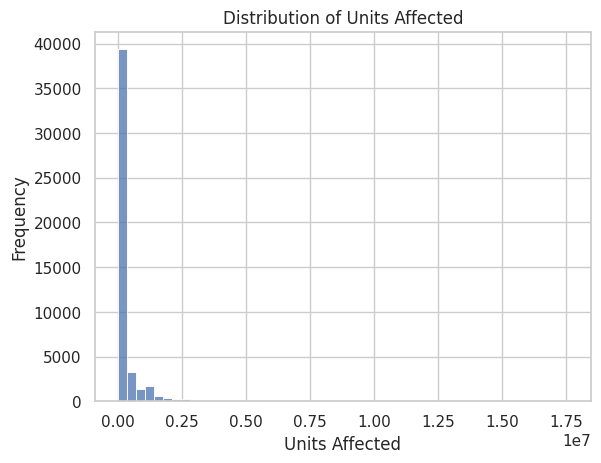

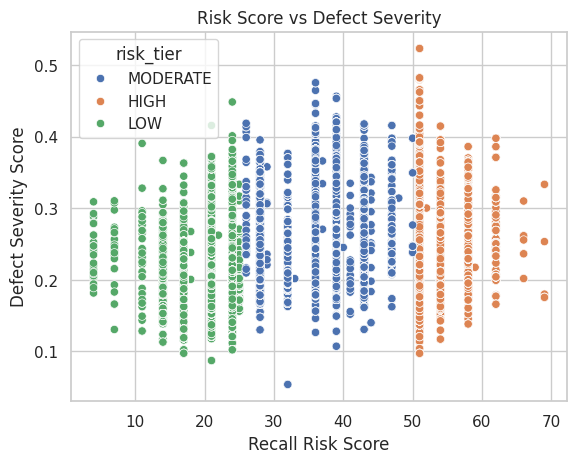

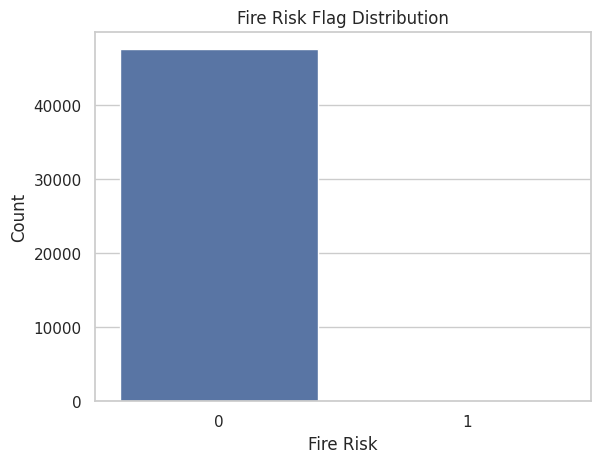

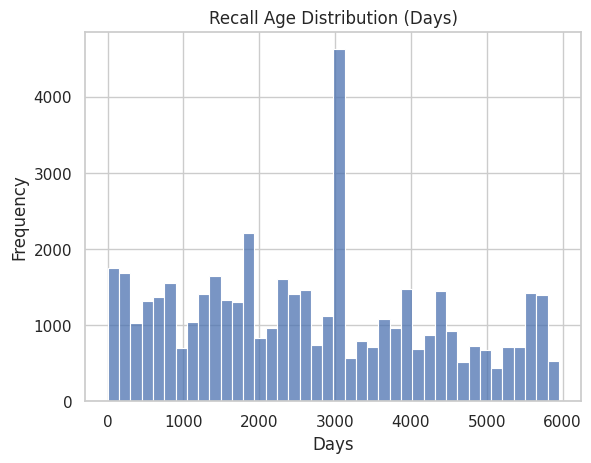

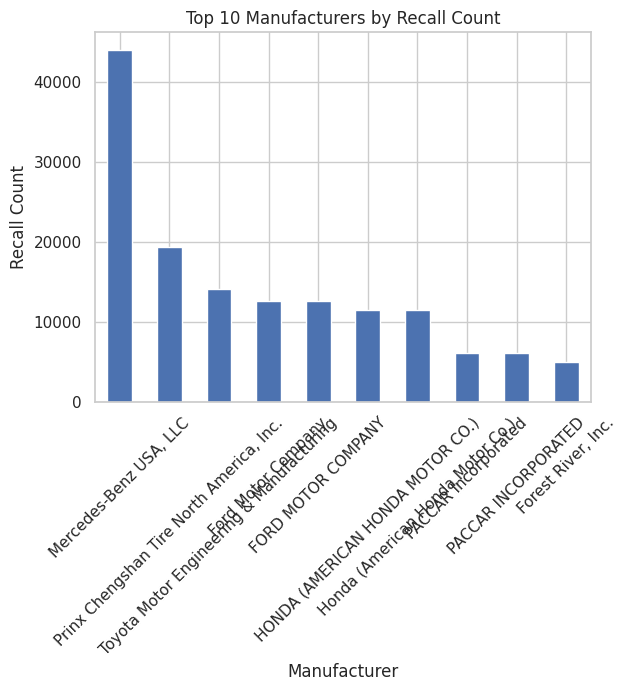

In [14]:
# Set style
sns.set(style="whitegrid")

# -------------------------------
# 1. Recalls per Year
# -------------------------------
plt.figure()
df['recall_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Recalls per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 2. Top 10 Vehicle Makes
# -------------------------------
plt.figure()
df['vehicle_make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Vehicle Makes with Most Recalls")
plt.xlabel("Vehicle Make")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 3. Recall Type Distribution
# -------------------------------
plt.figure()
df['recall_type_label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Recall Type Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# 4. Component Category Analysis
# -------------------------------
plt.figure()
df['component_category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Component Categories")
plt.xlabel("Component Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 5. Risk Tier Distribution
# -------------------------------
plt.figure()
sns.countplot(data=df, x='risk_tier')
plt.title("Risk Tier Distribution")
plt.xlabel("Risk Tier")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 6. Units Affected Distribution
# -------------------------------
plt.figure()
sns.histplot(df['units_affected_num'].dropna(), bins=50)
plt.title("Distribution of Units Affected")
plt.xlabel("Units Affected")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 7. Recall Risk Score vs Severity
# -------------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='recall_risk_score',
    y='defect_severity_score',
    hue='risk_tier'
)
plt.title("Risk Score vs Defect Severity")
plt.xlabel("Recall Risk Score")
plt.ylabel("Defect Severity Score")
plt.show()

# -------------------------------
# 8. Fire Risk Analysis
# -------------------------------
plt.figure()
sns.countplot(data=df, x='fire_risk_flag')
plt.title("Fire Risk Flag Distribution")
plt.xlabel("Fire Risk")
plt.ylabel("Count")
plt.show()

# -------------------------------
# 9. Recall Age Distribution
# -------------------------------
plt.figure()
sns.histplot(df['recall_age_days'].dropna(), bins=40)
plt.title("Recall Age Distribution (Days)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 10. Manufacturer Recall Count (Top 10)
# -------------------------------
plt.figure()
df.groupby('manufacturer_name')['manufacturer_recall_count'].max().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Manufacturers by Recall Count")
plt.xlabel("Manufacturer")
plt.ylabel("Recall Count")
plt.xticks(rotation=45)
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9993
AUC Score: 0.9984

Decision Tree
Accuracy: 0.9982
AUC Score: 0.7927

Random Forest
Accuracy: 0.9996
AUC Score: 0.9876


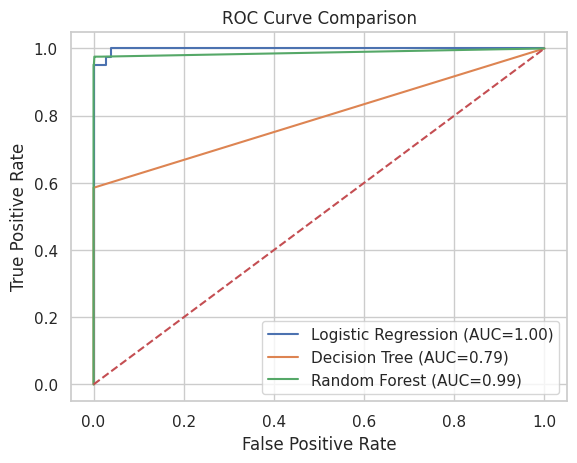

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# -------------------------------
# Target
# -------------------------------
target = 'fire_risk_flag'

df = df.dropna(subset=[target])
df[target] = df[target].astype(int)

# -------------------------------
# Drop leakage columns
# -------------------------------
leak_cols = [
    'defect_summary', 'consequence_summary', 'corrective_action',
    'notes', 'recall_risk_score', 'risk_tier', 'influenced_by'
]

df = df.drop(columns=[col for col in leak_cols if col in df.columns], errors='ignore')

# -------------------------------
# Split features/target
# -------------------------------
X = df.drop(columns=[target])
y = df[target]

# -------------------------------
# Column types
# -------------------------------
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# -------------------------------
# Pipelines
# -------------------------------
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# -------------------------------
# Training & Evaluation
# -------------------------------
plt.figure()

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    
    # ROC + AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"AUC Score: {auc:.4f}")
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# -------------------------------
# ROC Curve Plot
# -------------------------------
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!